# Proyecto Aplicado — Clasificación de stroke con LDA/QDA, KNN, árboles y ensambles

### Dataset: Stroke Prediction Dataset (Kaggle, fedesoriano): https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
### Objetivo: predecir si un paciente tuvo un stroke (stroke = 1) a partir de 10 variables clínicas y demográficas, comparando las cuatro familias de modelos de la unidad sobre el mismo train/test split.

--- 

### Equipo : 

#### Ángel Esqueda Ochoa 
#### Iván Reyes
#### Andoreni Claudio Flores Alcocer

---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid", context="notebook")
UP_BLUE, UP_RED, UP_GOLD = "#003366", "#BA0C2F", "#C69214"
SEED = 42  # una sola semilla para que todo sea reproducible

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Parte 1 - EDA

#### Revisamos lo que importa para clasificar con este dataset: tipos de variable, faltantes (los declarados y los escondidos), balance de clases y relación de cada predictor con stroke.

In [3]:
# tipos de variable y valores unicos por columna
resumen = pd.DataFrame({"tipo": df.dtypes.astype(str),
                        "valores_unicos": df.nunique(),
                        "faltantes": df.isna().sum(),
                        "% faltantes": (df.isna().mean() * 100).round(2)})
display(resumen)

numericas = ["age", "avg_glucose_level", "bmi"]
binarias = ["hypertension", "heart_disease"]
categoricas = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in categoricas:
    print("\n", df[col].value_counts())

,tipo,valores_unicos,faltantes,% faltantes
id,int64,5110,0,0.00
gender,str,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,str,2,0,0.00
work_type,str,5,0,0.00
Residence_type,str,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93



 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

 ever_married
Yes    3353
No     1757
Name: count, dtype: int64

 work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

 Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


stroke
0    4861
1     249
Name: count, dtype: int64
Tasa base de stroke: 4.87%
Accuracy de un modelo que siempre predice 'no stroke': 95.13%


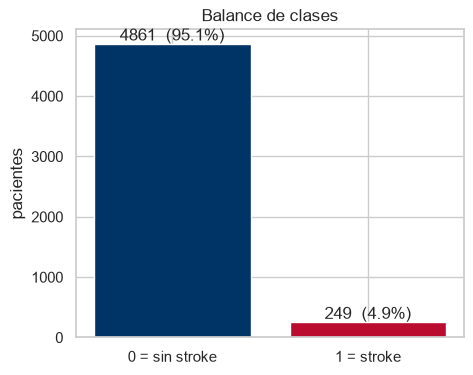

In [4]:
# balance de clases
conteo = df["stroke"].value_counts()
tasa_base = df["stroke"].mean()
print(conteo)
print(f"Tasa base de stroke: {tasa_base:.2%}")
print(f"Accuracy de un modelo que siempre predice 'no stroke': {1 - tasa_base:.2%}")

plt.figure(figsize=(5, 4))
plt.bar(["0 = sin stroke", "1 = stroke"], conteo.values, color=[UP_BLUE, UP_RED])
for i, v in enumerate(conteo.values):
    plt.text(i, v + 60, f"{v}  ({v / len(df):.1%})", ha="center")
plt.title("Balance de clases")
plt.ylabel("pacientes")
plt.show()

#### Solo ~5% de los pacientes tuvo un stroke. Un modelo que siempre diga "no stroke" tendría ~95% de accuracy sin haber aprendido nada, así que accuracy no puede ser nuestra métrica principal.

In [5]:
# faltantes "reales" (bmi) y faltantes "escondidos" (smoking_status == 'Unknown')
print("bmi faltante:", df["bmi"].isna().sum(), f"({df['bmi'].isna().mean():.1%})")
print("smoking_status == 'Unknown':", (df["smoking_status"] == "Unknown").sum(),
      f"({(df['smoking_status'] == 'Unknown').mean():.1%})")

# el faltante de bmi es al azar respecto al target?
tabla_bmi = (df.assign(bmi_faltante=df["bmi"].isna())
               .groupby("bmi_faltante")["stroke"].agg(n="size", strokes="sum", tasa="mean"))
print("\n", tabla_bmi)

# quienes son los 'Unknown' de tabaquismo?
print("\nEdad promedio por smoking_status:")
print(df.groupby("smoking_status")["age"].agg(["mean", "median"]).round(1))
print("\n% de menores de 18 dentro de 'Unknown':",
      f"{(df.loc[df['smoking_status'] == 'Unknown', 'age'] < 18).mean():.1%}")

bmi faltante: 201 (3.9%)
smoking_status == 'Unknown': 1544 (30.2%)

                  n  strokes      tasa
bmi_faltante                         
False         4909      209  0.042575
True           201       40  0.199005

Edad promedio por smoking_status:
                 mean  median
smoking_status               
Unknown          30.2    23.0
formerly smoked  54.9    57.0
never smoked     46.7    47.0
smokes           47.1    47.0

% de menores de 18 dentro de 'Unknown': 44.2%


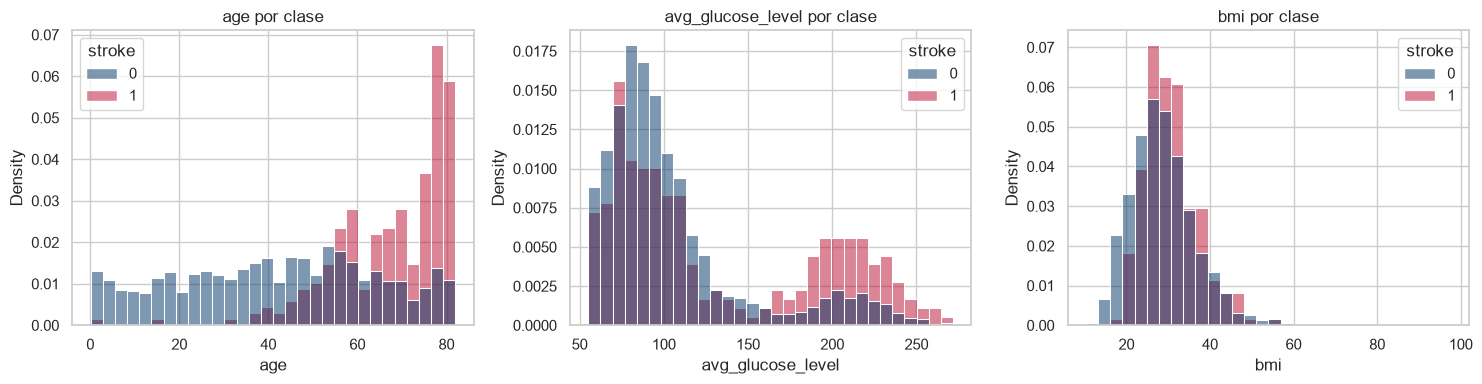

          age        avg_glucose_level           bmi      
         mean    std              mean    std   mean   std
stroke                                                    
0       41.97  22.29            104.80  43.85  28.82  7.91
1       67.73  12.73            132.54  61.92  30.47  6.33


In [6]:
# distribucion de las variables numericas dentro de cada clase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numericas):
    sns.histplot(data=df, x=col, hue="stroke", stat="density", common_norm=False,
                 bins=30, palette=[UP_BLUE, UP_RED], alpha=0.5, ax=ax)
    ax.set_title(f"{col} por clase")
plt.tight_layout()
plt.show()

print(df.groupby("stroke")[numericas].agg(["mean", "std"]).round(2))

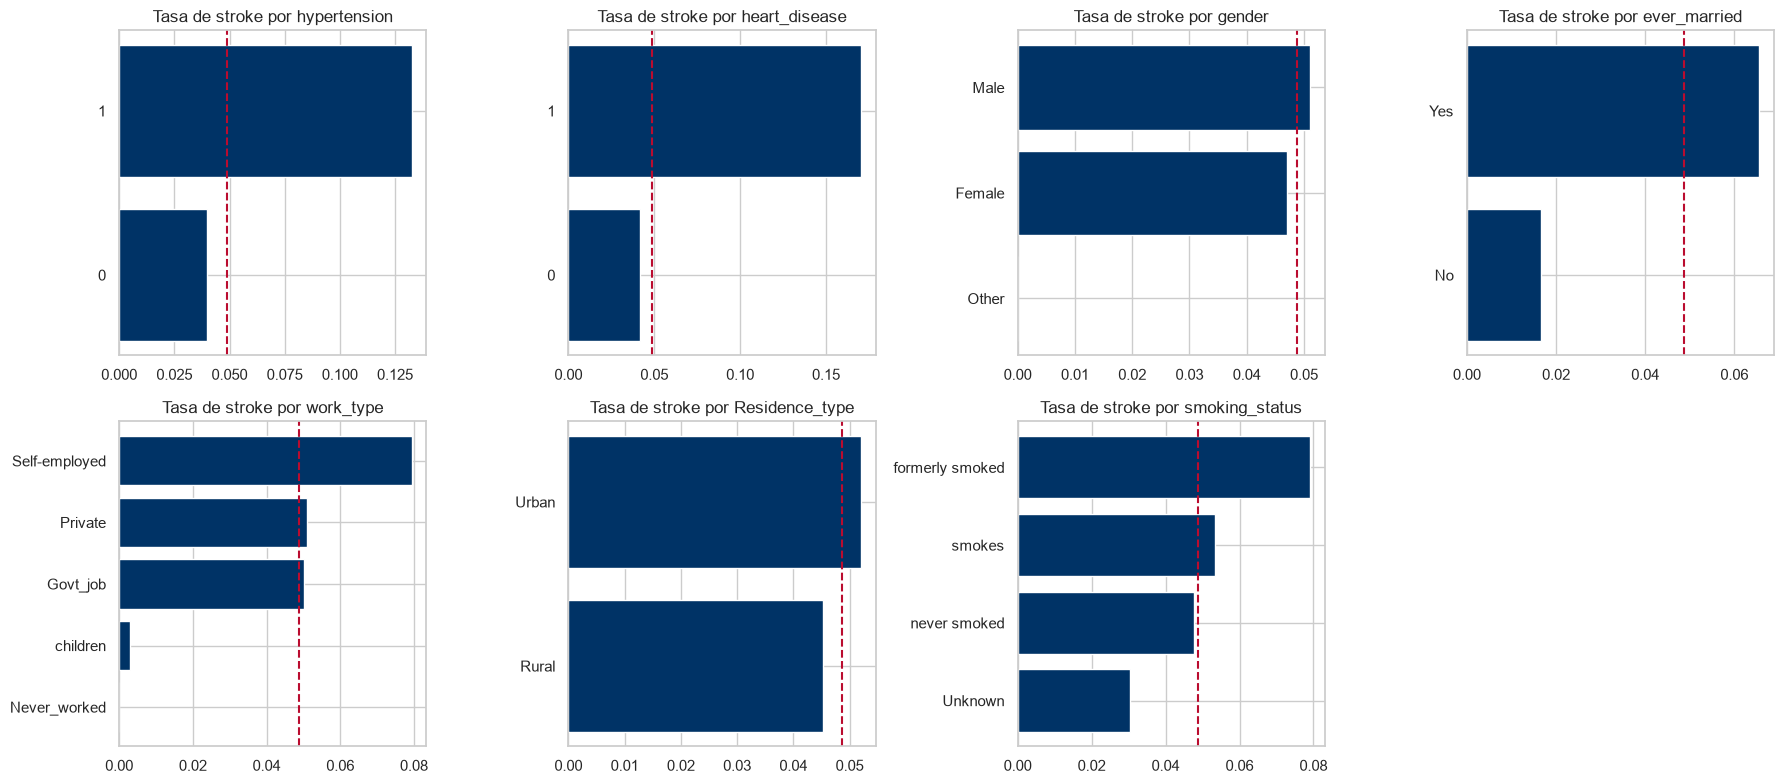

                  n  strokes
work_type                   
Govt_job        657       33
Never_worked     22        0
Private        2925      149
Self-employed   819       65
children        687        2
           n  strokes
gender               
Female  2994      141
Male    2115      108
Other      1        0


In [7]:
# tasa de stroke por categoria (la linea punteada es la tasa base)
cols_cat = binarias + categoricas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, cols_cat):
    tasas = df.groupby(col)["stroke"].mean().sort_values()
    ax.barh(tasas.index.astype(str), tasas.values, color=UP_BLUE)
    ax.axvline(tasa_base, color=UP_RED, ls="--", lw=1.5)
    ax.set_title(f"Tasa de stroke por {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

# categorias con muy pocos casos positivos
print(df.groupby("work_type")["stroke"].agg(n="size", strokes="sum"))
print(df.groupby("gender")["stroke"].agg(n="size", strokes="sum"))

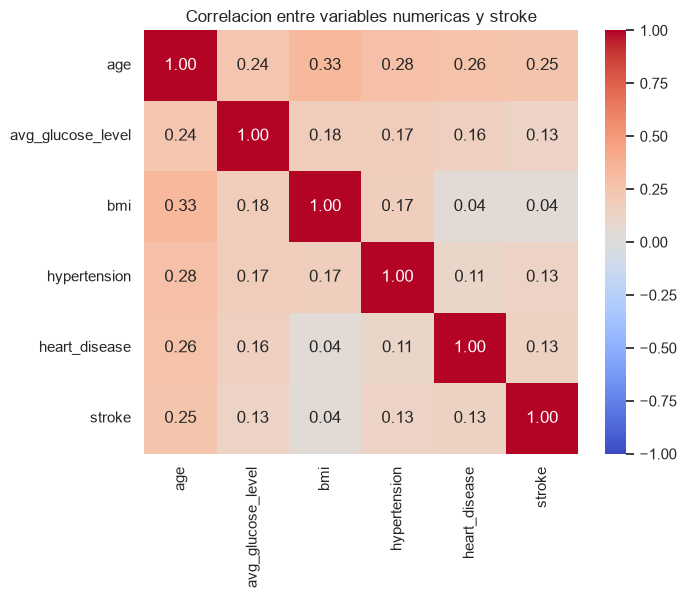

In [8]:
# correlacion entre variables numericas/binarias y el target
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[numericas + binarias + ["stroke"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1)
plt.title("Correlacion entre variables numericas y stroke")
plt.show()

---

## Parte 2 - Preparación y Split 

#### Parte 2 — Limpieza, matriz de diseño y train/test split
#### Quitamos id (no es un predictor) y la única observación con gender = Other.
#### Convertimos las categóricas a dummies.
#### Hacemos un solo split 75/25 para los cuatro modelos, estratificado para que train y test conserven el ~5% de positivos.
#### Imputamos bmi con la mediana de train. La calculamos solo con train para que el test no participe en ninguna decisión.
#### Usamos los mismos 5 folds (Clase 13) para elegir todos los hiperparámetros.

In [9]:
# limpieza especifica de este dataset
datos = df.drop(columns="id")                 # el id no es un predictor
datos = datos[datos["gender"] != "Other"]     # una sola observacion, no se puede aprender nada de ella

X = pd.get_dummies(datos.drop(columns="stroke"), columns=categoricas, drop_first=True).astype(float)
y = datos["stroke"]

print("Matriz de diseno:", X.shape)
print(list(X.columns))

Matriz de diseno: (5109, 15)
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [10]:
# un solo split para los cuatro modelos, estratificado para conservar el ~5% de positivos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)

# imputamos bmi con la mediana calculada SOLO en train (el test no participa en nada)
mediana_bmi = X_train["bmi"].median()
X_train = X_train.fillna({"bmi": mediana_bmi})
X_test = X_test.fillna({"bmi": mediana_bmi})

print(f"Mediana de bmi en train: {mediana_bmi}")
print(f"Train: {X_train.shape}, positivos = {y_train.sum()} ({y_train.mean():.2%})")
print(f"Test:  {X_test.shape}, positivos = {y_test.sum()} ({y_test.mean():.2%})")

# los mismos 5 folds para todos los modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Mediana de bmi en train: 28.0
Train: (3831, 15), positivos = 187 (4.88%)
Test:  (1278, 15), positivos = 62 (4.85%)


---

## Parte 3 - LDA vs QDA

#### LDA supone que X dentro de cada clase es normal multivariada con la misma covarianza Σ; QDA permite una Σₖ por clase (Clase 17). Revisamos los dos supuestos con gráficas y después dejamos que decida la validación cruzada.

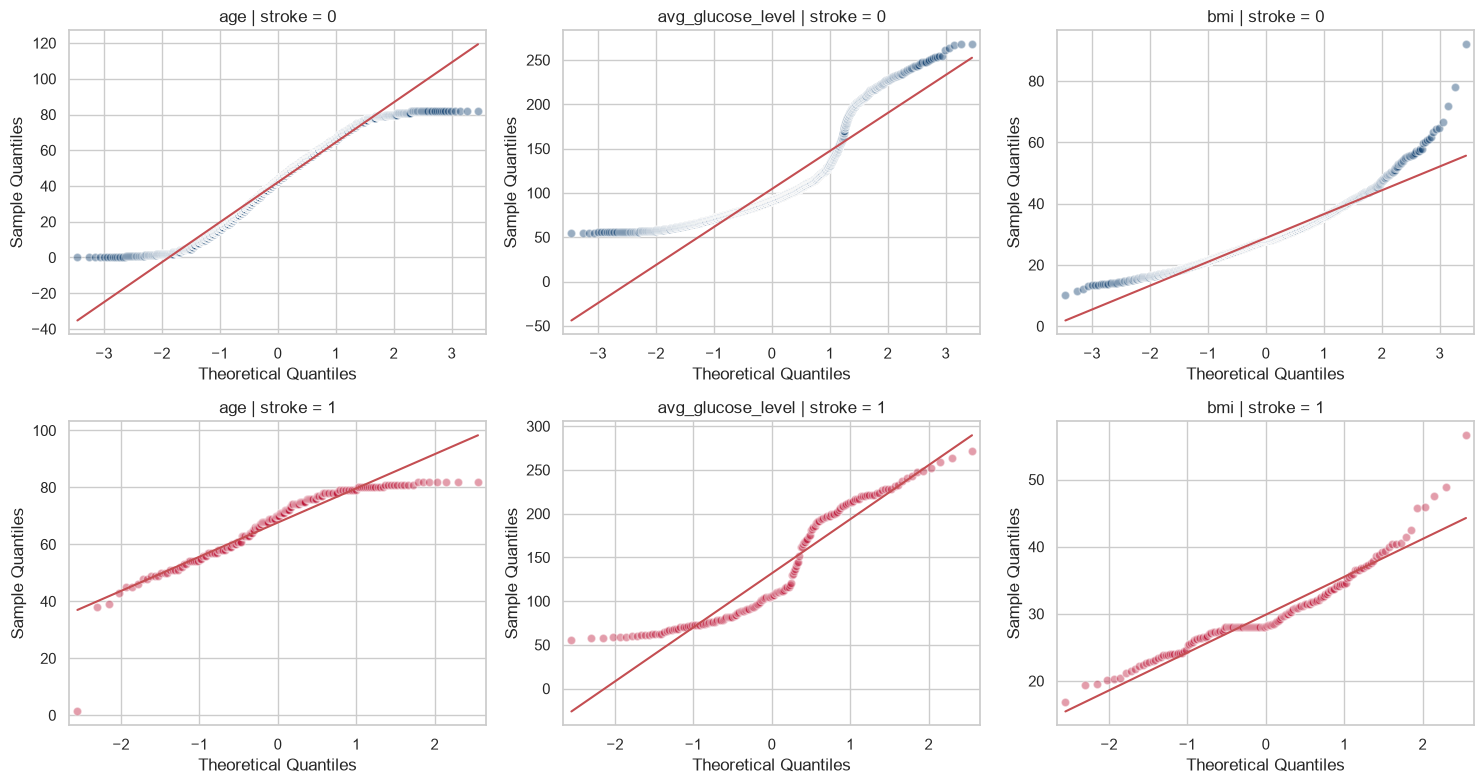

In [11]:
# supuesto de normalidad dentro de cada clase: QQ-plots de las variables continuas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for fila, clase in enumerate([0, 1]):
    for col_i, col in enumerate(numericas):
        valores = X_train.loc[y_train == clase, col]
        sm.qqplot(valores, line="s", ax=axes[fila, col_i],
                  markerfacecolor=UP_BLUE if clase == 0 else UP_RED,
                  markeredgecolor="white", alpha=0.4)
        axes[fila, col_i].set_title(f"{col} | stroke = {clase}")
plt.tight_layout()
plt.show()

In [12]:
# supuesto de covarianza compartida: se parece la dispersion entre clases?
print("Desviacion estandar por clase:")
print(X_train.groupby(y_train)[numericas].std().round(2))

for clase in [0, 1]:
    print(f"\nMatriz de covarianza de las continuas, stroke = {clase}:")
    print(X_train.loc[y_train == clase, numericas].cov().round(1))

# se puede estimar una covarianza propia para la clase positiva con TODOS los predictores?
p = X_train.shape[1]
n_pos = int(y_train.sum())
sigma_1 = np.cov(X_train[y_train == 1].values, rowvar=False)
print(f"\nPredictores p = {p}, parametros por matriz de covarianza p(p+1)/2 = {p * (p + 1) // 2}")
print(f"Positivos en train = {n_pos}")
print(f"Rango de la covarianza de la clase 1: {np.linalg.matrix_rank(sigma_1)} de {p}")
print("\nDummies con varianza cero dentro de la clase 1:")
print(X_train[y_train == 1].std().loc[lambda s: s == 0])

Desviacion estandar por clase:
          age  avg_glucose_level   bmi
stroke                                
0       22.36              42.91  7.78
1       12.04              61.97  5.66

Matriz de covarianza de las continuas, stroke = 0:
                     age  avg_glucose_level   bmi
age                500.1              208.8  59.4
avg_glucose_level  208.8             1841.2  50.6
bmi                 59.4               50.6  60.5

Matriz de covarianza de las continuas, stroke = 1:
                     age  avg_glucose_level    bmi
age                144.9               23.9  -19.3
avg_glucose_level   23.9             3839.9  114.8
bmi                -19.3              114.8   32.0

Predictores p = 15, parametros por matriz de covarianza p(p+1)/2 = 120
Positivos en train = 187
Rango de la covarianza de la clase 1: 14 de 15

Dummies con varianza cero dentro de la clase 1:
work_type_Never_worked    0.0
dtype: float64


In [13]:
# LDA vs QDA por validacion cruzada (AUC), como pide la regla practica de la Clase 17
# QDA solo se puede estimar con variables que tengan varianza en ambas clases,
# asi que lo comparamos contra LDA en ese mismo subconjunto
clinicas = numericas + binarias

candidatos = {
    "LDA (todos los predictores)": (LinearDiscriminantAnalysis(), list(X_train.columns)),
    "LDA (5 clinicas)": (LinearDiscriminantAnalysis(), clinicas),
    "QDA (5 clinicas)": (QuadraticDiscriminantAnalysis(), clinicas),
    "LDA (3 continuas)": (LinearDiscriminantAnalysis(), numericas),
    "QDA (3 continuas)": (QuadraticDiscriminantAnalysis(), numericas),
}

filas = []
for nombre, (modelo, cols) in candidatos.items():
    scores = cross_val_score(modelo, X_train[cols], y_train, cv=cv, scoring="roc_auc")
    filas.append({"modelo": nombre, "AUC CV promedio": scores.mean(), "desv. est. entre folds": scores.std()})
tabla_da = pd.DataFrame(filas).set_index("modelo").round(4)
display(tabla_da)

,AUC CV promedio,desv. est. entre folds
modelo,,
LDA (todos los predictores),0.8321,0.0356
LDA (5 clinicas),0.8333,0.0373
QDA (5 clinicas),0.8297,0.0333
LDA (3 continuas),0.8347,0.0416
QDA (3 continuas),0.8385,0.0325


In [14]:
# modelo discriminante final: LDA con todos los predictores
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
auc_cv_lda = tabla_da.loc["LDA (todos los predictores)", "AUC CV promedio"]

print("Priors estimados (pi_k):", lda.priors_.round(4))
print("\nCoeficientes de la funcion discriminante (escala original de cada variable):")
print(pd.Series(lda.coef_[0], index=X_train.columns).sort_values().round(3))

Priors estimados (pi_k): [0.9512 0.0488]

Coeficientes de la funcion discriminante (escala original de cada variable):
ever_married_Yes                 -0.760
smoking_status_never smoked      -0.176
work_type_Self-employed          -0.128
gender_Male                      -0.065
bmi                              -0.022
smoking_status_formerly smoked   -0.018
avg_glucose_level                 0.008
smoking_status_smokes             0.048
age                               0.071
Residence_type_Urban              0.071
work_type_Private                 0.206
work_type_Never_worked            0.693
hypertension                      0.905
heart_disease                     0.953
work_type_children                1.258
dtype: float64


--- 

## Parte 4 - KNN

#### KNN clasifica por distancia euclidiana, así que primero estandarizamos (si no, la glucosa, que va de 55 a 270, pesaría mucho más que una dummy 0/1). Probamos dos conjuntos de predictores, los 15 y solo las 5 variables clínicas, porque la Clase 17 advierte que KNN sufre con muchos predictores.

In [15]:
# KNN: escalamos dentro de un Pipeline para que la media y desv. est. se calculen solo
# con los folds de entrenamiento (la distancia euclidiana depende de las unidades)
Ks = [1, 5, 11, 21, 31, 51, 75, 101, 151, 201, 301, 401, 501, 701, 1001]

def buscar_knn(columnas):
    pipe = Pipeline([("escala", StandardScaler()), ("knn", KNeighborsClassifier())])
    busqueda = GridSearchCV(pipe, {"knn__n_neighbors": Ks}, cv=cv, scoring="roc_auc", n_jobs=-1)
    busqueda.fit(X_train[columnas], y_train)
    return busqueda

knn_todas = buscar_knn(list(X_train.columns))   # los 15 predictores
knn_clinicas = buscar_knn(clinicas)             # solo 5 predictores

for nombre, b in [("15 predictores", knn_todas), ("5 clinicas", knn_clinicas)]:
    print(f"KNN ({nombre}): mejor K = {b.best_params_['knn__n_neighbors']}, AUC CV = {b.best_score_:.4f}")

KNN (15 predictores): mejor K = 1001, AUC CV = 0.8058
KNN (5 clinicas): mejor K = 501, AUC CV = 0.8380


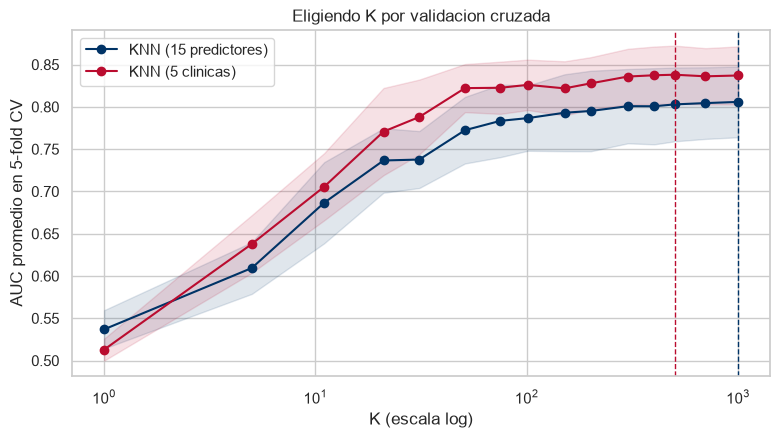

KNN final: {'knn__n_neighbors': 501} con 5 predictores


In [16]:
# AUC de validacion cruzada como funcion de K
plt.figure(figsize=(9, 4.5))
for nombre, b, color in [("15 predictores", knn_todas, UP_BLUE), ("5 clinicas", knn_clinicas, UP_RED)]:
    media = b.cv_results_["mean_test_score"]
    desv = b.cv_results_["std_test_score"]
    plt.plot(Ks, media, marker="o", color=color, label=f"KNN ({nombre})")
    plt.fill_between(Ks, media - desv, media + desv, color=color, alpha=0.12)
    plt.axvline(b.best_params_["knn__n_neighbors"], color=color, ls="--", lw=1)
plt.xscale("log")
plt.xlabel("K (escala log)")
plt.ylabel("AUC promedio en 5-fold CV")
plt.title("Eligiendo K por validacion cruzada")
plt.legend()
plt.show()

# nos quedamos con el conjunto de predictores que gana en CV
if knn_clinicas.best_score_ > knn_todas.best_score_:
    knn, cols_knn = knn_clinicas, clinicas
else:
    knn, cols_knn = knn_todas, list(X_train.columns)
print("KNN final:", knn.best_params_, "con", len(cols_knn), "predictores")

---

## Parte 5 - Árbol de decisión 

#### Seguimos los tres pasos de la Clase 19: dejar crecer el árbol hasta un mínimo de observaciones por hoja, penalizar el número de hojas con α y elegir por CV. Probamos varios mínimos por hoja; para cada uno, los α candidatos salen de su ruta de poda. El criterio de corte es Gini.